# Sierra Leone Solar EDA
**Station:** Bumbuna  
**Goal:** Profile, clean, and explore the Sierra Leone solar dataset.


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# 1. Load the data
df = pd.read_csv(
    r'../data/Sierra Leonne/sierraleone-bumbuna.csv',
    encoding='latin1',
    skiprows=[1]
)

print(f'Rows: {len(df)}, Columns: {len(df.columns)}')
df.head()

Rows: 525599, Columns: 19


,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
0,2021-10-30 00:02,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.2,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN
1,2021-10-30 00:03,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.2,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN
2,2021-10-30 00:04,-0.7,0.0,-0.8,0.0,0.0,21.9,99.3,0.0,0.0,0.0,0.0,0.0,1002,0,0.1,22.3,22.6,NaN
3,2021-10-30 00:05,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.3,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN
4,2021-10-30 00:06,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.3,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.7,NaN


## 1. Summary Statistics & Missing Value Report

In [ ]:
# Summary statistics
print('Summary Statistics:')
display(df.describe()) 

# Missing value report
print('\nMissing Values per Column:')
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
display(missing_report[missing_report['Missing Count'] > 0])

Summary Statistics:


,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
count,525599.000000,525599.000000,525599.000000,525599.000000,525599.000000,525599.000000,525599.000000,525599.000000,525599.000000,525599.000000,525599.000000,525599.000000,525599.000000,525599.000000,525599.000000,525599.000000,525599.000000,0.0
mean,201.957901,116.376559,113.720788,206.643488,198.115068,26.319403,79.448820,1.146115,1.691609,0.363824,133.044922,7.172233,999.876465,0.000967,0.004806,32.504283,32.593110,NaN
std,298.495303,218.652808,158.946105,300.897044,288.889218,4.398605,20.520776,1.239249,1.617053,0.295000,114.284753,7.535094,2.104419,0.031074,0.047556,12.434902,12.009165,NaN
min,-19.500000,-7.800000,-17.900000,0.000000,0.000000,12.300000,9.900000,0.000000,0.000000,0.000000,0.000000,0.000000,993.000000,0.000000,0.000000,10.700000,11.100000,NaN
25%,-2.800000,-0.300000,-3.800000,0.000000,0.000000,23.100000,68.700000,0.000000,0.000000,0.000000,0.000000,0.000000,999.000000,0.000000,0.000000,23.500000,23.800000,NaN
50%,0.300000,-0.100000,-0.100000,3.600000,3.400000,25.300000,85.400000,0.800000,1.600000,0.400000,161.500000,6.200000,1000.000000,0.000000,0.000000,26.600000,26.900000,NaN
75%,362.400000,107.000000,224.700000,359.500000,345.400000,29.400000,96.700000,2.000000,2.600000,0.600000,234.100000,12.000000,1001.000000,0.000000,0.000000,40.900000,41.300000,NaN
max,1499.000000,946.000000,892.000000,1507.000000,1473.000000,39.900000,100.000000,19.200000,23.900000,4.100000,360.000000,98.400000,1006.000000,1.000000,2.400000,72.800000,70.400000,NaN



Missing Values per Column:


,Missing Count,Missing %
Comments,525599,100.0


## 2. Outlier Detection & Data Cleaning

In [4]:
# Drop the empty Comments column if it exists
if 'Comments' in df.columns:
    df = df.drop(columns=['Comments'])

# Count negative values in radiation columns
radiation_cols = ['GHI', 'DNI', 'DHI']
print('Negative values in radiation columns:')
print((df[radiation_cols] < 0).sum())

# Detect outliers using Z-scores
cols_to_check = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']
z_scores = np.abs(stats.zscore(df[cols_to_check]))
outliers_mask = (z_scores > 3).any(axis=1)
print(f'\nRows flagged as outliers: {outliers_mask.sum()}')
print(f'Percentage: {(outliers_mask.sum() / len(df) * 100):.2f}%')

Negative values in radiation columns:
GHI    261134
DNI    266351
DHI    263127
dtype: int64

Rows flagged as outliers: 16292
Percentage: 3.10%


In [5]:
# Fix negatives: set to 0 (night-time sensor noise)
for col in ['GHI', 'DNI', 'DHI']:
    df.loc[df[col] < 0, col] = 0

# Remove outlier rows
df_clean = df[~outliers_mask].copy()

# Convert Timestamp to datetime
df_clean['Timestamp'] = pd.to_datetime(df_clean['Timestamp'])

print(f'Original rows: {len(df)}')
print(f'Cleaned rows:  {len(df_clean)}')

Original rows: 525599
Cleaned rows:  509307


## 3. Time Series Analysis

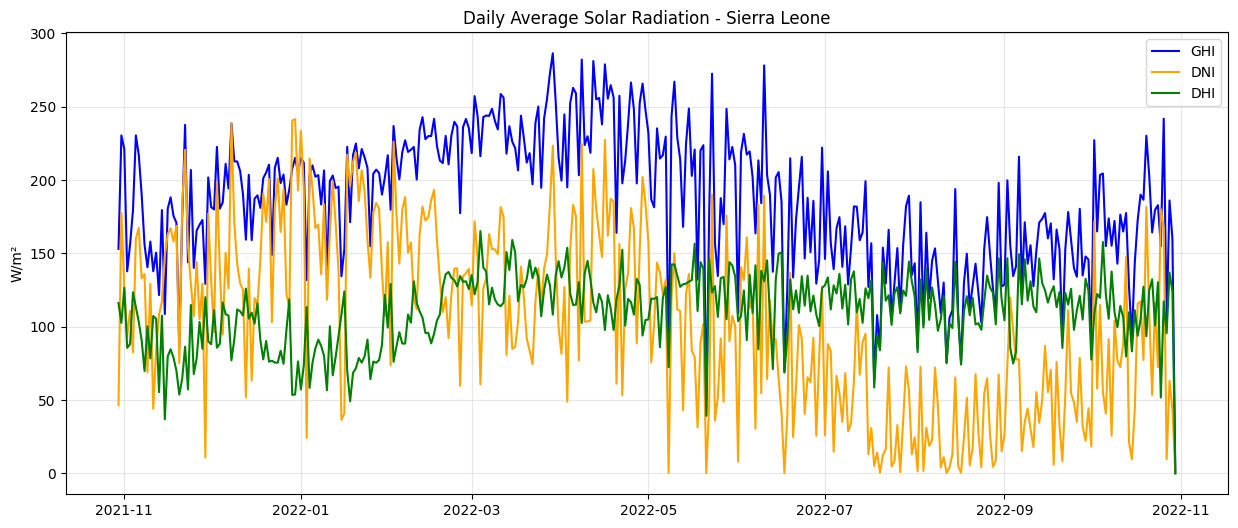

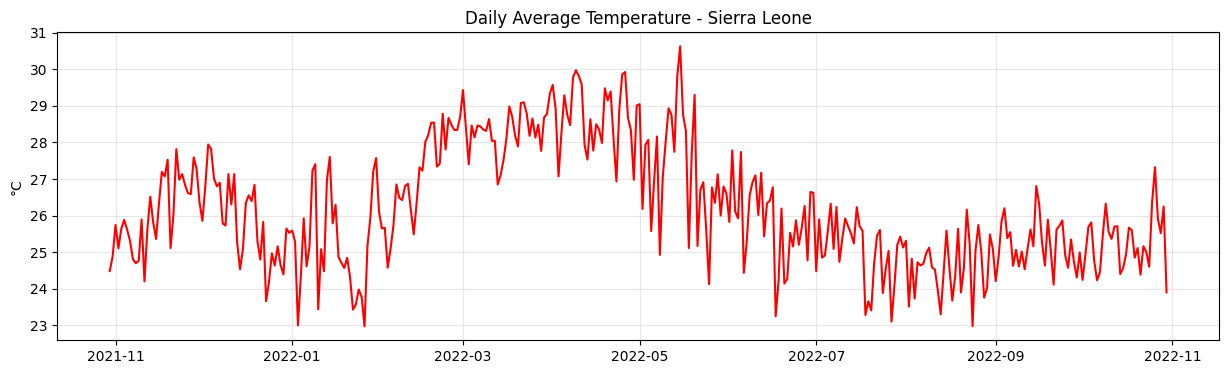

In [6]:
# Daily average solar radiation over time
sample_data = df_clean.set_index('Timestamp').resample('D').mean(numeric_only=True)

plt.figure(figsize=(15, 6))
plt.plot(sample_data.index, sample_data['GHI'], label='GHI', color='blue')
plt.plot(sample_data.index, sample_data['DNI'], label='DNI', color='orange')
plt.plot(sample_data.index, sample_data['DHI'], label='DHI', color='green')
plt.title('Daily Average Solar Radiation - Sierra Leone')
plt.ylabel('W/m²')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Ambient temperature over time
plt.figure(figsize=(15, 4))
plt.plot(sample_data.index, sample_data['Tamb'], color='red')
plt.title('Daily Average Temperature - Sierra Leone')
plt.ylabel('°C')
plt.grid(True, alpha=0.3)
plt.show()

## 4. Cleaning Impact

Average Sensor Readings (Cleaned vs Uncleaned):


,ModA,ModB
Cleaning,,
0,189.681153,181.598878
1,273.309252,277.231102


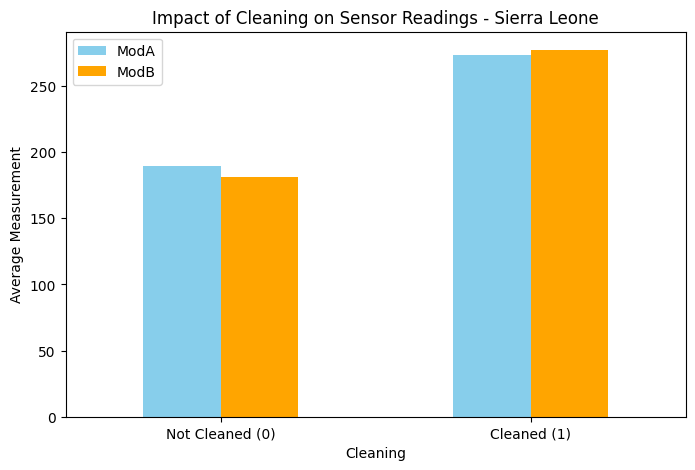

In [7]:
cleaning_impact = df_clean.groupby('Cleaning')[['ModA', 'ModB']].mean()
print('Average Sensor Readings (Cleaned vs Uncleaned):')
display(cleaning_impact)

cleaning_impact.plot(kind='bar', figsize=(8, 5), color=['skyblue', 'orange'])
plt.title('Impact of Cleaning on Sensor Readings - Sierra Leone')
plt.ylabel('Average Measurement')
plt.xticks([0, 1], ['Not Cleaned (0)', 'Cleaned (1)'], rotation=0)
plt.show()

## 5. Correlation Heatmap

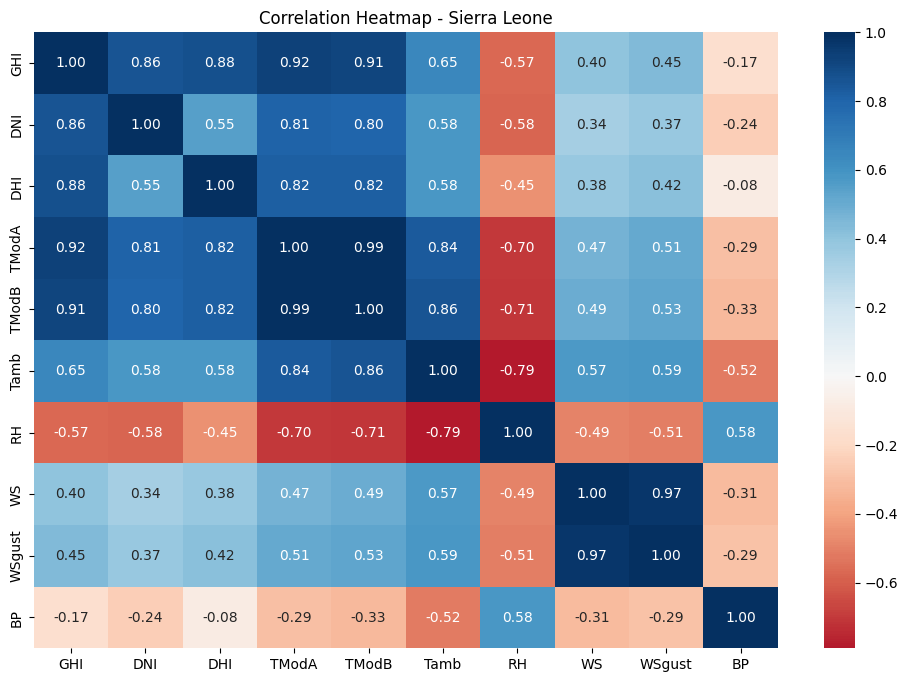

In [8]:
corr_cols = ['GHI', 'DNI', 'DHI', 'TModA', 'TModB', 'Tamb', 'RH', 'WS', 'WSgust', 'BP']
correlation_matrix = df_clean[corr_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu', center=0, fmt='.2f')
plt.title('Correlation Heatmap - Sierra Leone')
plt.show()

## 6. Wind & Distribution Analysis

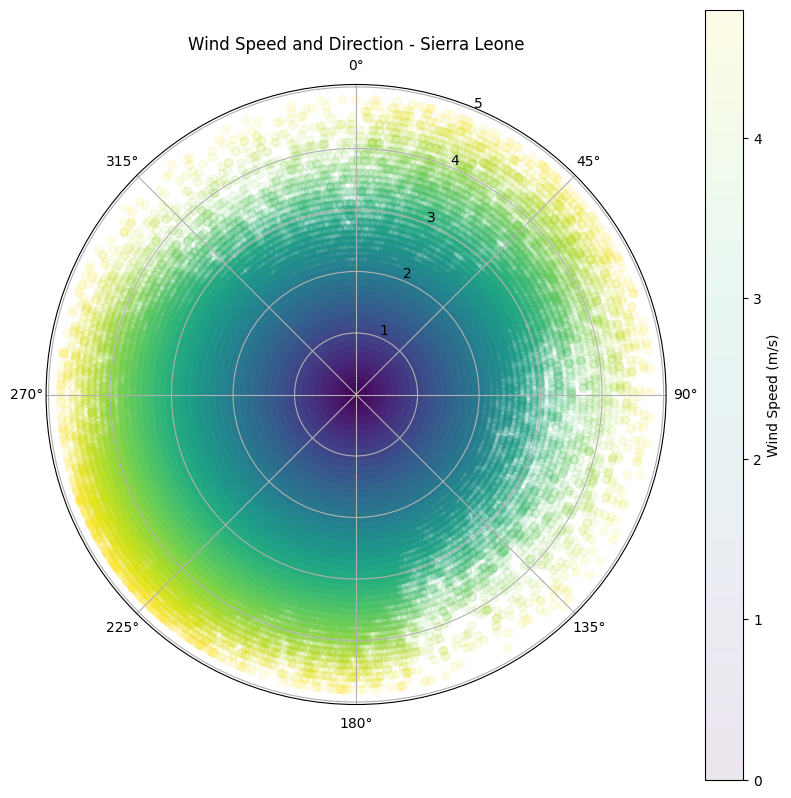

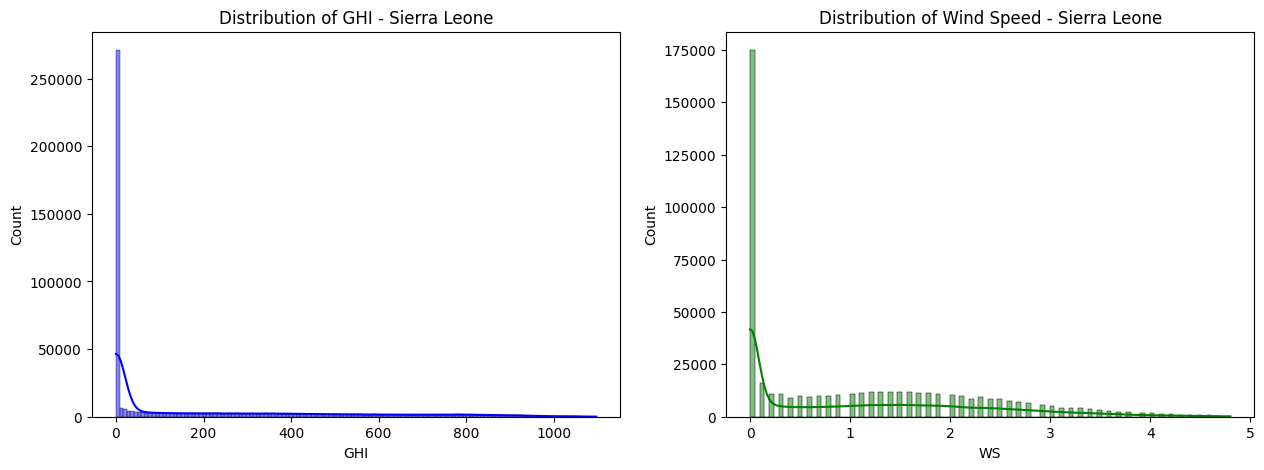

In [9]:
# Wind Rose
plt.figure(figsize=(10, 10))
ax = plt.subplot(111, polar=True)
ax.set_theta_direction(-1)
ax.set_theta_zero_location('N')
plt.scatter(np.deg2rad(df_clean['WD']), df_clean['WS'], alpha=0.1, c=df_clean['WS'], cmap='viridis')
plt.colorbar(label='Wind Speed (m/s)')
plt.title('Wind Speed and Direction - Sierra Leone')
plt.show()

# Histograms
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_clean['GHI'], kde=True, color='blue')
plt.title('Distribution of GHI - Sierra Leone')

plt.subplot(1, 2, 2)
sns.histplot(df_clean['WS'], kde=True, color='green')
plt.title('Distribution of Wind Speed - Sierra Leone')
plt.show()

## 7. Bubble Chart

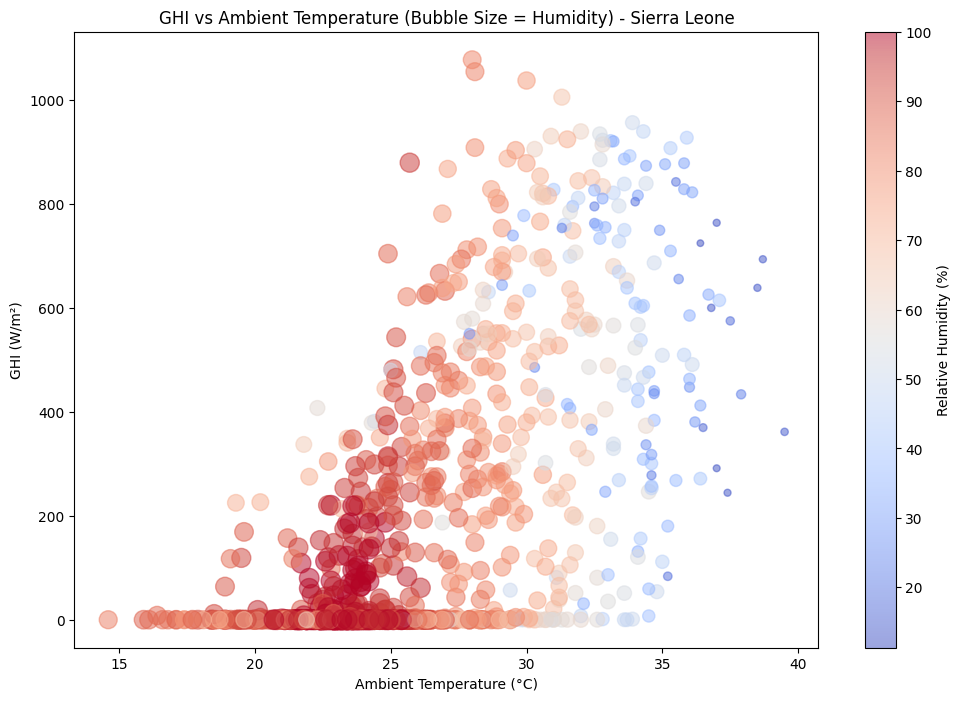

In [10]:
sample_bubble = df_clean.sample(1000, random_state=42)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    sample_bubble['Tamb'],
    sample_bubble['GHI'],
    s=sample_bubble['RH'] * 2,
    alpha=0.5,
    c=sample_bubble['RH'],
    cmap='coolwarm'
)
plt.colorbar(scatter, label='Relative Humidity (%)')
plt.title('GHI vs Ambient Temperature (Bubble Size = Humidity) - Sierra Leone')
plt.xlabel('Ambient Temperature (°C)')
plt.ylabel('GHI (W/m²)')
plt.show()

## 8. Export Cleaned Data

In [11]:
df_clean.to_csv('../data/sierraleone_clean.csv', index=False)
print('Sierra Leone cleaned data saved to data/sierraleone_clean.csv ✅')

Sierra Leone cleaned data saved to data/sierraleone_clean.csv ✅
